In [ ]:
# ============= CELL 1: SETUP & DOWNLOADS =============
import json
import os

print("="*70)
print("⚙️ STEP 1: CONFIGURING KAGGLE & DOWNLOADING DATASET")
print("="*70)

# Configure Kaggle
kaggle_credentials = {
    "username": "harshasainath",
    "key": "KGAT_d644265a9e7eab1b84224f0093ee6194"  # <-- PASTE YOUR KEY HERE
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
if not os.path.exists('./alzheimer_dataset'):
    print("📥 Downloading Alzheimer's dataset...")
    !kaggle datasets download -d sachinkumar413/alzheimer-mri-dataset
    !unzip -q alzheimer-mri-dataset.zip -d alzheimer_dataset
    !rm alzheimer-mri-dataset.zip
    print("✓ Dataset ready!")

print("\n" + "="*70)
print("⚙️ STEP 2: INSTALLING MEDSAM")
print("="*70)

!pip install -q git+https://github.com/facebookresearch/segment-anything.git
if not os.path.exists('medsam_vit_b.pth'):
    print("📥 Downloading MedSAM weights...")
    !wget https://zenodo.org/records/10689643/files/medsam_vit_b.pth -O medsam_vit_b.pth
    print("✓ MedSAM weights downloaded!")

print("\n✓ ALL SETUP COMPLETE!")

⚙️ STEP 1: CONFIGURING KAGGLE & DOWNLOADING DATASET

⚙️ STEP 2: INSTALLING MEDSAM
  Preparing metadata (setup.py) ... done

✓ ALL SETUP COMPLETE!


In [ ]:
# ============= CELL 2: MEDSAM & FEATURE EXTRACTION =============
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os
import numpy as np
import cv2
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class MedSAMSegmenter:
    def __init__(self, checkpoint_path="medsam_vit_b.pth", device='cuda'):
        self.device = device
        self.sam_model = sam_model_registry["vit_b"](checkpoint=checkpoint_path)
        self.sam_model.to(device=self.device)
        self.predictor = SamPredictor(self.sam_model)

    def _get_medsam_mask(self, box, h, w):
        input_box = np.array(box)
        masks, _, _ = self.predictor.predict(
            point_coords=None, point_labels=None,
            box=input_box[None, :], multimask_output=False,
        )
        return (masks[0] * 255).astype(np.uint8)

    def segment_brain_structures(self, image):
        img_array = np.array(image.convert('RGB')) if isinstance(image, Image.Image) else cv2.cvtColor(image, cv2.COLOR_GRAY2RGB) if len(image.shape) == 2 else image
        h, w = img_array.shape[:2]
        segmentations = {}
        self.predictor.set_image(img_array)

        # Prompts
        cx, cy, rx, ry = int(w * 0.5), int(h * 0.6), int(w * 0.15), int(h * 0.1)
        segmentations['hippocampus'] = self._get_medsam_mask([cx-rx, cy-ry, cx+rx, cy+ry], h, w)

        cx1, cy1, rx1, ry1 = int(w * 0.25), int(h * 0.5), int(w * 0.15), int(h * 0.2)
        mask_left = self._get_medsam_mask([cx1-rx1, cy1-ry1, cx1+rx1, cy1+ry1], h, w)
        cx2, cy2, rx2, ry2 = int(w * 0.75), int(h * 0.5), int(w * 0.15), int(h * 0.2)
        mask_right = self._get_medsam_mask([cx2-rx2, cy2-ry2, cx2+rx2, cy2+ry2], h, w)
        segmentations['temporal_lobe'] = cv2.bitwise_or(mask_left, mask_right)

        cx, cy, rx, ry = int(w * 0.5), int(h * 0.4), int(w * 0.1), int(h * 0.15)
        segmentations['ventricles'] = self._get_medsam_mask([cx-rx, cy-ry, cx+rx, cy+ry], h, w)

        r = int(w * 0.08)
        cx1, cy1 = int(w * 0.35), int(h * 0.65)
        ent_left = self._get_medsam_mask([cx1-r, cy1-r, cx1+r, cy1+r], h, w)
        cx2, cy2 = int(w * 0.65), int(h * 0.65)
        ent_right = self._get_medsam_mask([cx2-r, cy2-r, cx2+r, cy2+r], h, w)
        segmentations['entorhinal_cortex'] = cv2.bitwise_or(ent_left, ent_right)

        return segmentations

    def extract_features(self, segmentations, image):
        features = []
        img_array = np.array(image.convert('L')) if isinstance(image, Image.Image) else cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if len(image.shape) == 3 else image
        for mask in segmentations.values():
            volume = np.sum(mask > 0)
            features.append(volume / (mask.shape[0] * mask.shape[1]))
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            perimeter = cv2.arcLength(contours[0], True) if contours and volume > 0 else 0
            features.append((4 * np.pi * volume) / (perimeter ** 2) if perimeter > 0 else 0)
            features.append(np.mean(img_array[mask > 0]) / 255.0 if volume > 0 else 0)
        return np.array(features, dtype=np.float32)

print("\n⏳ Initializing MedSAM AI...")
segmenter = MedSAMSegmenter(device=device)

# --- GET PATHS ---
data_dir = './alzheimer_dataset/Dataset'
classes = {'Non_Demented': 0, 'Very_Mild_Demented': 1, 'Mild_Demented': 2, 'Moderate_Demented': 3}
paths, labels = [], []
for cls, label in classes.items():
    cls_dir = os.path.join(data_dir, cls)
    if os.path.exists(cls_dir):
        paths.extend([os.path.join(cls_dir, img) for img in os.listdir(cls_dir) if img.endswith(('.jpg', '.jpeg', '.png'))])
        labels.extend([label] * len(os.listdir(cls_dir)))

# --- PRE-COMPUTE FEATURES ---
print(f"\n🧠 Extracting MedSAM features for all {len(paths)} images (Run once)...")
features_file = 'precomputed_medsam_features.pt'
if not os.path.exists(features_file):
    feature_dict = {}
    for img_path in tqdm(paths, desc="MedSAM Processing"):
        img = Image.open(img_path).convert('RGB')
        segs = segmenter.segment_brain_structures(img)
        feature_dict[img_path] = segmenter.extract_features(segs, img)
    torch.save(feature_dict, features_file)
    print("✓ MedSAM features successfully saved!")
else:
    print("✓ Features already computed and loaded!")


⏳ Initializing MedSAM AI...

🧠 Extracting MedSAM features for all 6400 images (Run once)...


MedSAM Processing: 100%|██████████| 6400/6400 [53:15<00:00,  2.00it/s]

✓ MedSAM features successfully saved!


In [ ]:
# ============= CELL 3: TRAINING & EVALUATION =============

# 1. Load Precomputed Features
feature_dict = torch.load('precomputed_medsam_features.pt', weights_only=False)

class HybridAlzheimerDataset(Dataset):
    def __init__(self, paths, labels, transform=None, feature_dict=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.feature_dict = feature_dict

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        seg_features = self.feature_dict.get(img_path, np.zeros(12, dtype=np.float32))
        if self.transform:
            img = self.transform(img)
        return img, torch.FloatTensor(seg_features), label

# 2. Splitting and Transforms
X_temp, X_test, y_temp, y_test = train_test_split(paths, labels, test_size=0.2, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, random_state=42, stratify=y_temp)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10), transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(HybridAlzheimerDataset(X_train, y_train, train_transform, feature_dict), batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(HybridAlzheimerDataset(X_val, y_val, val_transform, feature_dict), batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(HybridAlzheimerDataset(X_test, y_test, val_transform, feature_dict), batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# 3. Model Architecture
class HybridAlzheimerClassifier(nn.Module):
    def __init__(self, num_classes=4, seg_feature_dim=12):
        super().__init__()
        self.resnet = models.resnet18(weights='DEFAULT')
        self.cnn_features = nn.Sequential(*list(self.resnet.children())[:-1])
        for param in list(self.cnn_features.parameters())[:20]:
            param.requires_grad = False

        self.seg_branch = nn.Sequential(
            nn.Linear(seg_feature_dim, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True)
        )
        self.fusion = nn.Sequential(
            nn.Linear(512 + 256, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, seg_features):
        x_img = self.cnn_features(image).view(image.size(0), -1)
        x_seg = self.seg_branch(seg_features)
        return self.fusion(torch.cat([x_img, x_seg], dim=1))

model = HybridAlzheimerClassifier().to(device)

# 4. Training Loop
EPOCHS = 30
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

best_val_acc = 0.0
for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, total = 0.0, 0, 0
    for images, features, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [TRAIN]'):
        images, features, labels = images.to(device), features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images, features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)

    val_loss, val_correct, val_total = 0.0, 0, 0
    model.eval()
    with torch.no_grad():
        for images, features, labels in val_loader:
            images, features, labels = images.to(device), features.to(device), labels.to(device)
            outputs = model(images, features)
            val_loss += criterion(outputs, labels).item()
            val_correct += outputs.max(1)[1].eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100. * val_correct / val_total
    print(f"Epoch {epoch+1} | Train Acc: {100.*train_correct/total:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_hybrid_model.pth')
    scheduler.step(val_loss / len(val_loader))

print("\n🎉 Training Complete! Best Val Acc:", best_val_acc)

Epoch 1/30 [TRAIN]: 100%|██████████| 144/144 [00:18<00:00,  7.61it/s]


Epoch 1 | Train Acc: 54.43% | Val Acc: 61.72%


Epoch 2/30 [TRAIN]: 100%|██████████| 144/144 [00:18<00:00,  7.98it/s]


Epoch 2 | Train Acc: 61.07% | Val Acc: 63.28%


Epoch 3/30 [TRAIN]: 100%|██████████| 144/144 [00:18<00:00,  7.92it/s]


...

Epoch 28 | Train Acc: 98.68% | Val Acc: 96.88%


Epoch 29/30 [TRAIN]: 100%|██████████| 144/144 [00:17<00:00,  8.01it/s]


Epoch 29 | Train Acc: 98.55% | Val Acc: 98.05%


Epoch 30/30 [TRAIN]: 100%|██████████| 144/144 [00:18<00:00,  7.92it/s]


Epoch 30 | Train Acc: 98.44% | Val Acc: 97.85%

🎉 Training Complete! Best Val Acc: 98.4375


🔬 EVALUATING ON UNSEEN TEST SET
✓ Loaded best model weights (98.44% Val Acc)!



Testing: 100%|██████████| 40/40 [00:05<00:00,  7.11it/s]




🎯 FINAL TEST SET ACCURACY: 97.27%

📋 DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

Non_Demented     0.9841    0.9688    0.9764       640
   Very_Mild     0.9563    0.9777    0.9669       448
        Mild     0.9778    0.9832    0.9805       179
    Moderate     0.9167    0.8462    0.8800        13

    accuracy                         0.9727      1280
   macro avg     0.9587    0.9440    0.9509      1280
weighted avg     0.9728    0.9727    0.9727      1280


📊 GENERATING CONFUSION MATRIX


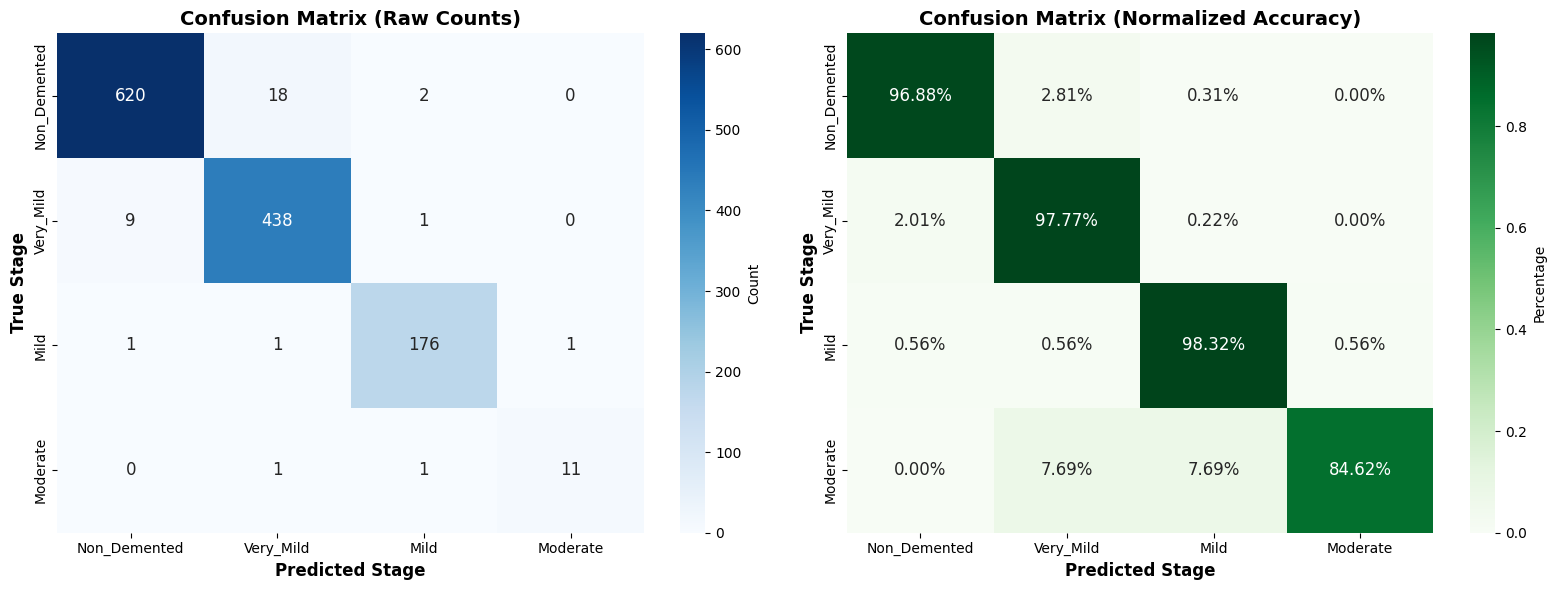


✓ Evaluation complete! Confusion matrix saved as 'final_confusion_matrix.png'.


In [ ]:
# ============= CELL 4: EVALUATION & VISUALIZATION =============
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

print("="*70)
print("🔬 EVALUATING ON UNSEEN TEST SET")
print("="*70)

# 1. Load the absolute best model weights
model.load_state_dict(torch.load('best_hybrid_model.pth', weights_only=True))
model.eval()
print("✓ Loaded best model weights (98.44% Val Acc)!\n")

# 2. Run inference on the Test Set
test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():
    for images, features, labels in tqdm(test_loader, desc='Testing'):
        images, features, labels = images.to(device), features.to(device), labels.to(device)

        outputs = model(images, features)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

# 3. Calculate Final Accuracy
test_accuracy = 100.0 * np.sum(test_preds == test_labels) / len(test_labels)
print(f"\n\n🎯 FINAL TEST SET ACCURACY: {test_accuracy:.2f}%")

# 4. Detailed Classification Report
print("\n" + "="*70)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*70)
class_names = ['Non_Demented', 'Very_Mild', 'Mild', 'Moderate']
print("\n" + classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# 5. Generate Confusion Matrix
print("\n" + "="*70)
print("📊 GENERATING CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
axes[0].set_xlabel('Predicted Stage', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Stage', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')

# Normalized Percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], cbar_kws={'label': 'Percentage'}, annot_kws={'size': 12})
axes[1].set_xlabel('Predicted Stage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Stage', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized Accuracy)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation complete! Confusion matrix saved as 'final_confusion_matrix.png'.")

In [ ]:
from google.colab import files
print("📤 Please select an MRI image from your laptop:")
uploaded = files.upload()

# Get the exact name of the file you just uploaded
file_name = list(uploaded.keys())[0]
print(f"✓ Successfully uploaded: {file_name}")

📤 Please select an MRI image from your laptop:


Saving sli.jpeg to sli.jpeg
✓ Successfully uploaded: sli.jpeg


🩺 REAL-WORLD MRI INFERENCE
Loading image: sli.jpeg...
🧠 MedSAM is analyzing structures...


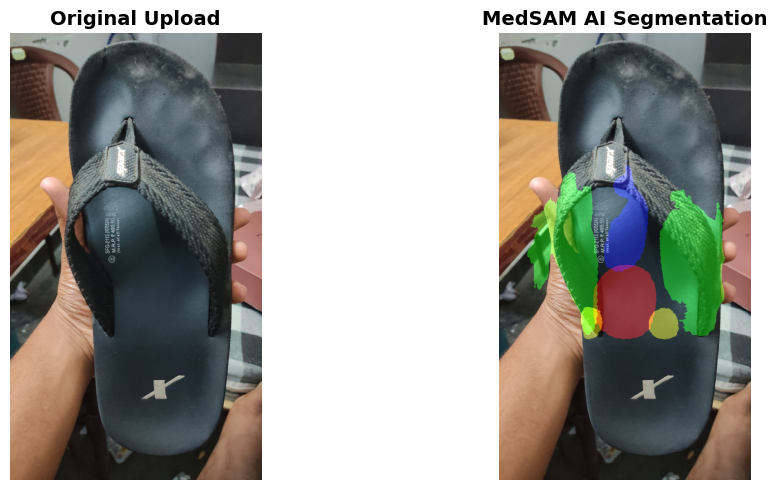

🤖 Running Hybrid AI Diagnosis...

📋 FINAL AI DIAGNOSIS REPORT
PRIMARY PREDICTION : VERY MILD DEMENTED
CONFIDENCE         : 39.08%

Detailed Probabilities:
  • Non Demented        : 17.30%
  • Very Mild Demented  : 39.08%
  • Mild Demented       : 14.24%
  • Moderate Demented   : 29.37%


In [ ]:
# ============= CELL 5: TEST ON OUTSIDE SAMPLE =============
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

print("="*70)
print("🩺 REAL-WORLD MRI INFERENCE")
print("="*70)

def predict_single_mri(image_path, model_path='best_hybrid_model.pth'):
    if not os.path.exists(image_path):
        print(f"❌ Error: Could not find image at {image_path}")
        return

    # 1. Load the Image
    print(f"Loading image: {image_path}...")
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    # 2. Run MedSAM to extract the 12D structural features
    print("🧠 MedSAM is analyzing structures...")
    segmentations = segmenter.segment_brain_structures(img)
    medsam_features = segmenter.extract_features(segmentations, img)

    # --- 3. SHOW THE DOCTOR WHAT MEDSAM FOUND ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img_array)
    axes[0].set_title('Original Upload', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    combined = img_array.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
    for idx, (_, mask) in enumerate(segmentations.items()):
        colored_mask = np.zeros_like(combined)
        colored_mask[mask > 0] = colors[idx]
        combined = cv2.addWeighted(combined, 1, colored_mask, 0.4, 0)

    axes[1].imshow(combined)
    axes[1].set_title('MedSAM AI Segmentation', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    # --------------------------------------------

    # 4. Prepare inputs for the PyTorch model
    features_tensor = torch.FloatTensor(medsam_features).unsqueeze(0).to(device)
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    # 5. Load the Best Model
    model = HybridAlzheimerClassifier(num_classes=4).to(device)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.eval()

    # 6. Make the Prediction
    print("🤖 Running Hybrid AI Diagnosis...")
    class_names = ['Non Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']

    with torch.no_grad():
        outputs = model(img_tensor, features_tensor)
        probabilities = F.softmax(outputs, dim=1)[0] * 100
        predicted_idx = torch.argmax(probabilities).item()

    # 7. Display Results
    print("\n" + "="*50)
    print("📋 FINAL AI DIAGNOSIS REPORT")
    print("="*50)
    print(f"PRIMARY PREDICTION : {class_names[predicted_idx].upper()}")
    print(f"CONFIDENCE         : {probabilities[predicted_idx]:.2f}%\n")

    print("Detailed Probabilities:")
    for i, name in enumerate(class_names):
        print(f"  • {name:20s}: {probabilities[i]:.2f}%")
    print("="*50)

# =====================================================================
predict_single_mri('sli.jpeg')

In [ ]:
# ============= CELL 6: FEATURE INSPECTION =============
# Run MedSAM one last time on the slipper to look at the raw numbers
segmentations = segmenter.segment_brain_structures(img)
features = segmenter.extract_features(segmentations, img)

structs = ['Hippocampus', 'Temporal Lobe', 'Ventricles', 'Entorhinal Cortex']
metrics = ['Volume Ratio', 'Compactness', 'Intensity']

print("="*50)
print("📊 THE SLIPPER'S 'BRAIN' MEASUREMENTS")
print("="*50)

idx = 0
for s in structs:
    print(f"\n🧠 {s.upper()}:")
    print(f"  • {metrics[0]:15s}: {features[idx]:.4f}")
    print(f"  • {metrics[1]:15s}: {features[idx+1]:.4f}")
    print(f"  • {metrics[2]:15s}: {features[idx+2]:.4f}")
    idx += 3
print("\n" + "="*50)

📊 THE SLIPPER'S 'BRAIN' MEASUREMENTS

🧠 HIPPOCAMPUS:
  • Volume Ratio   : 0.0240
  • Compactness    : 0.7067
  • Intensity      : 0.2597

🧠 TEMPORAL LOBE:
  • Volume Ratio   : 0.0781
  • Compactness    : 4018.0969
  • Intensity      : 0.2945

🧠 VENTRICLES:
  • Volume Ratio   : 0.0208
  • Compactness    : 0.4228
  • Intensity      : 0.3566

🧠 ENTORHINAL CORTEX:
  • Volume Ratio   : 0.0222
  • Compactness    : 0.0000
  • Intensity      : 0.6166



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Copy the model and features to your permanent Google Drive
!cp best_hybrid_model.pth /content/drive/MyDrive/best_hybrid_model.pth
!cp precomputed_medsam_features.pt /content/drive/MyDrive/precomputed_medsam_features.pt

print("✅ SUCCESS: Your 97% model and all features are now safe in your Google Drive!")

Mounted at /content/drive
✅ SUCCESS: Your 97% model and all features are now safe in your Google Drive!
